### Analytical expressions for quadratic fits

In [1]:
# Import SymPy
import sympy as smp

In [2]:
# Define symbols
x = smp.IndexedBase('x', real = True, constant = True)
y = smp.IndexedBase('y', real = True, constant = True)
deltay = smp.IndexedBase('Delta_y', real = True, positive = True, constant = True)

N = smp.symbols('N', integer = True, positive = True, constant = True)
k = smp.Idx('k', range = (1, N))

In [3]:
def equations(expr, symbols: list): # Computes the linear system to solve
    return [smp.diff(expr, s, 1).expand().cancel().doit() for s in symbols]

def solve(eqs: list, symbols: list): # Solves and simplifies the linear system

    sol = smp.linsolve(eqs, symbols)
    solution = next(iter(sol))
    simplified = tuple(smp.simplify(comp) for comp in solution)
    
    return simplified

In [4]:
# Linear fit
m, q = smp.symbols('m q', real = True, nonzero = True)
symbols = [m, q]

sum_of_squared_residual = smp.Sum(((m * x[k] + q - y[k]) ** 2 / (deltay[k]) ** 2), (k, 1, N)) 
sum_of_squared_residual

Sum((m*x[k] + q - y[k])**2/Delta_y[k]**2, (k, 1, N))

In [5]:
eqs = equations(sum_of_squared_residual, symbols)
eqs

[2*m*Sum(x[k]**2/Delta_y[k]**2, (k, 1, N)) + 2*q*Sum(x[k]/Delta_y[k]**2, (k, 1, N)) - 2*Sum(x[k]*y[k]/Delta_y[k]**2, (k, 1, N)),
 2*m*Sum(x[k]/Delta_y[k]**2, (k, 1, N)) + 2*q*Sum(Delta_y[k]**(-2), (k, 1, N)) - 2*Sum(y[k]/Delta_y[k]**2, (k, 1, N))]

In [6]:
solution = solve(eqs, symbols)
solution

(Sum((x[k]*Sum(y[k]/Delta_y[k]**2, (k, 1, N)) - Sum(x[k]*y[k]/Delta_y[k]**2, (k, 1, N)))/((Sum(x[k]/Delta_y[k]**2, (k, 1, N))**2 - Sum(x[k]**2/Delta_y[k]**2, (k, 1, N))*Sum(Delta_y[k]**(-2), (k, 1, N)))*Delta_y[k]**2), (k, 1, N)),
 Sum((-x[k]*Sum(y[k]/Delta_y[k]**2, (k, 1, N)) + Sum(x[k]*y[k]/Delta_y[k]**2, (k, 1, N)))*x[k]/((Sum(x[k]/Delta_y[k]**2, (k, 1, N))**2 - Sum(x[k]**2/Delta_y[k]**2, (k, 1, N))*Sum(Delta_y[k]**(-2), (k, 1, N)))*Delta_y[k]**2), (k, 1, N)))

In [7]:
solution[0] # m

Sum((x[k]*Sum(y[k]/Delta_y[k]**2, (k, 1, N)) - Sum(x[k]*y[k]/Delta_y[k]**2, (k, 1, N)))/((Sum(x[k]/Delta_y[k]**2, (k, 1, N))**2 - Sum(x[k]**2/Delta_y[k]**2, (k, 1, N))*Sum(Delta_y[k]**(-2), (k, 1, N)))*Delta_y[k]**2), (k, 1, N))

In [8]:
solution[1] # q

Sum((-x[k]*Sum(y[k]/Delta_y[k]**2, (k, 1, N)) + Sum(x[k]*y[k]/Delta_y[k]**2, (k, 1, N)))*x[k]/((Sum(x[k]/Delta_y[k]**2, (k, 1, N))**2 - Sum(x[k]**2/Delta_y[k]**2, (k, 1, N))*Sum(Delta_y[k]**(-2), (k, 1, N)))*Delta_y[k]**2), (k, 1, N))

In [9]:
# Quadratic fit
c0, c1, c2 = smp.symbols('c_0 c_1 c_2', real = True, nonzero = True)
symbols = [c0, c1, c2]

sum_of_squared_residual = smp.Sum(((c0 + c1 * x[k] + c2 * x[k] ** 2 - y[k]) ** 2 / (deltay[k] ** 2)), (k, 1, N)) 
sum_of_squared_residual

Sum((c_0 + c_1*x[k] + c_2*x[k]**2 - y[k])**2/Delta_y[k]**2, (k, 1, N))

In [10]:
eqs = equations(sum_of_squared_residual, symbols)
eqs

[2*c_0*Sum(Delta_y[k]**(-2), (k, 1, N)) + 2*c_1*Sum(x[k]/Delta_y[k]**2, (k, 1, N)) + 2*c_2*Sum(x[k]**2/Delta_y[k]**2, (k, 1, N)) - 2*Sum(y[k]/Delta_y[k]**2, (k, 1, N)),
 2*c_0*Sum(x[k]/Delta_y[k]**2, (k, 1, N)) + 2*c_1*Sum(x[k]**2/Delta_y[k]**2, (k, 1, N)) + 2*c_2*Sum(x[k]**3/Delta_y[k]**2, (k, 1, N)) - 2*Sum(x[k]*y[k]/Delta_y[k]**2, (k, 1, N)),
 2*c_0*Sum(x[k]**2/Delta_y[k]**2, (k, 1, N)) + 2*c_1*Sum(x[k]**3/Delta_y[k]**2, (k, 1, N)) + 2*c_2*Sum(x[k]**4/Delta_y[k]**2, (k, 1, N)) - 2*Sum(x[k]**2*y[k]/Delta_y[k]**2, (k, 1, N))]

In [11]:
solution = solve(eqs, symbols)
solution

(Sum(((x[k]**2*Sum(x[k]**2/Delta_y[k]**2, (k, 1, N))**2 + Sum(x[k]**3/Delta_y[k]**2, (k, 1, N))**2)*y[k] + x[k]**4*Sum(x[k]/Delta_y[k]**2, (k, 1, N))*Sum(x[k]*y[k]/Delta_y[k]**2, (k, 1, N)) - x[k]**3*Sum(x[k]/Delta_y[k]**2, (k, 1, N))*Sum(x[k]**2*y[k]/Delta_y[k]**2, (k, 1, N)) - x[k]**2*Sum(x[k]**3/Delta_y[k]**2, (k, 1, N))*Sum(x[k]*y[k]/Delta_y[k]**2, (k, 1, N)) - x[k]**2*Sum(x[k]**4/Delta_y[k]**2, (k, 1, N))*Sum(y[k]/Delta_y[k]**2, (k, 1, N)))/((Sum(x[k]**2/Delta_y[k]**2, (k, 1, N))**3 + Sum(Sum(x[k]**3/Delta_y[k]**2, (k, 1, N))**2/Delta_y[k]**2, (k, 1, N)) + Sum(x[k]**4*Sum(x[k]/Delta_y[k]**2, (k, 1, N))**2/Delta_y[k]**2, (k, 1, N)) - Sum(Sum(x[k]**2/Delta_y[k]**2, (k, 1, N))*Sum(x[k]**4/Delta_y[k]**2, (k, 1, N))/Delta_y[k]**2, (k, 1, N)) - 2*Sum(x[k]**2*Sum(x[k]/Delta_y[k]**2, (k, 1, N))*Sum(x[k]**3/Delta_y[k]**2, (k, 1, N))/Delta_y[k]**2, (k, 1, N)))*Delta_y[k]**2), (k, 1, N)),
 Sum((x[k]**4*Sum(x[k]/Delta_y[k]**2, (k, 1, N))*Sum(y[k]/Delta_y[k]**2, (k, 1, N)) - x[k]**2*Sum(x[k]/D

In [12]:
solution[0] # c0

Sum(((x[k]**2*Sum(x[k]**2/Delta_y[k]**2, (k, 1, N))**2 + Sum(x[k]**3/Delta_y[k]**2, (k, 1, N))**2)*y[k] + x[k]**4*Sum(x[k]/Delta_y[k]**2, (k, 1, N))*Sum(x[k]*y[k]/Delta_y[k]**2, (k, 1, N)) - x[k]**3*Sum(x[k]/Delta_y[k]**2, (k, 1, N))*Sum(x[k]**2*y[k]/Delta_y[k]**2, (k, 1, N)) - x[k]**2*Sum(x[k]**3/Delta_y[k]**2, (k, 1, N))*Sum(x[k]*y[k]/Delta_y[k]**2, (k, 1, N)) - x[k]**2*Sum(x[k]**4/Delta_y[k]**2, (k, 1, N))*Sum(y[k]/Delta_y[k]**2, (k, 1, N)))/((Sum(x[k]**2/Delta_y[k]**2, (k, 1, N))**3 + Sum(Sum(x[k]**3/Delta_y[k]**2, (k, 1, N))**2/Delta_y[k]**2, (k, 1, N)) + Sum(x[k]**4*Sum(x[k]/Delta_y[k]**2, (k, 1, N))**2/Delta_y[k]**2, (k, 1, N)) - Sum(Sum(x[k]**2/Delta_y[k]**2, (k, 1, N))*Sum(x[k]**4/Delta_y[k]**2, (k, 1, N))/Delta_y[k]**2, (k, 1, N)) - 2*Sum(x[k]**2*Sum(x[k]/Delta_y[k]**2, (k, 1, N))*Sum(x[k]**3/Delta_y[k]**2, (k, 1, N))/Delta_y[k]**2, (k, 1, N)))*Delta_y[k]**2), (k, 1, N))

In [13]:
solution[1] # c1

Sum((x[k]**4*Sum(x[k]/Delta_y[k]**2, (k, 1, N))*Sum(y[k]/Delta_y[k]**2, (k, 1, N)) - x[k]**2*Sum(x[k]/Delta_y[k]**2, (k, 1, N))*Sum(x[k]**2*y[k]/Delta_y[k]**2, (k, 1, N)) - x[k]**2*Sum(x[k]**3/Delta_y[k]**2, (k, 1, N))*Sum(y[k]/Delta_y[k]**2, (k, 1, N)) + x[k]*y[k]*Sum(x[k]**2/Delta_y[k]**2, (k, 1, N))**2 + Sum(x[k]**3/Delta_y[k]**2, (k, 1, N))*Sum(x[k]**2*y[k]/Delta_y[k]**2, (k, 1, N)) - Sum(x[k]**4/Delta_y[k]**2, (k, 1, N))*Sum(x[k]*y[k]/Delta_y[k]**2, (k, 1, N)))/((Sum(x[k]**2/Delta_y[k]**2, (k, 1, N))**3 + Sum(Sum(x[k]**3/Delta_y[k]**2, (k, 1, N))**2/Delta_y[k]**2, (k, 1, N)) + Sum(x[k]**4*Sum(x[k]/Delta_y[k]**2, (k, 1, N))**2/Delta_y[k]**2, (k, 1, N)) - Sum(Sum(x[k]**2/Delta_y[k]**2, (k, 1, N))*Sum(x[k]**4/Delta_y[k]**2, (k, 1, N))/Delta_y[k]**2, (k, 1, N)) - 2*Sum(x[k]**2*Sum(x[k]/Delta_y[k]**2, (k, 1, N))*Sum(x[k]**3/Delta_y[k]**2, (k, 1, N))/Delta_y[k]**2, (k, 1, N)))*Delta_y[k]**2), (k, 1, N))

In [14]:
solution[2] # c2

Sum((-x[k]**3*Sum(x[k]/Delta_y[k]**2, (k, 1, N))*Sum(y[k]/Delta_y[k]**2, (k, 1, N)) + x[k]**2*y[k]*Sum(x[k]/Delta_y[k]**2, (k, 1, N))**2 - x[k]**2*Sum(x[k]/Delta_y[k]**2, (k, 1, N))*Sum(x[k]*y[k]/Delta_y[k]**2, (k, 1, N)) + y[k]*Sum(x[k]**2/Delta_y[k]**2, (k, 1, N))**2 - Sum(x[k]**2/Delta_y[k]**2, (k, 1, N))*Sum(x[k]**2*y[k]/Delta_y[k]**2, (k, 1, N)) + Sum(x[k]**3/Delta_y[k]**2, (k, 1, N))*Sum(x[k]*y[k]/Delta_y[k]**2, (k, 1, N)))/((Sum(x[k]**2/Delta_y[k]**2, (k, 1, N))**3 + Sum(Sum(x[k]**3/Delta_y[k]**2, (k, 1, N))**2/Delta_y[k]**2, (k, 1, N)) + Sum(x[k]**4*Sum(x[k]/Delta_y[k]**2, (k, 1, N))**2/Delta_y[k]**2, (k, 1, N)) - Sum(Sum(x[k]**2/Delta_y[k]**2, (k, 1, N))*Sum(x[k]**4/Delta_y[k]**2, (k, 1, N))/Delta_y[k]**2, (k, 1, N)) - 2*Sum(x[k]**2*Sum(x[k]/Delta_y[k]**2, (k, 1, N))*Sum(x[k]**3/Delta_y[k]**2, (k, 1, N))/Delta_y[k]**2, (k, 1, N)))*Delta_y[k]**2), (k, 1, N))

Let's test the quadratic fit formulas

In [15]:
import numpy as np
import matplotlib.pyplot as plt

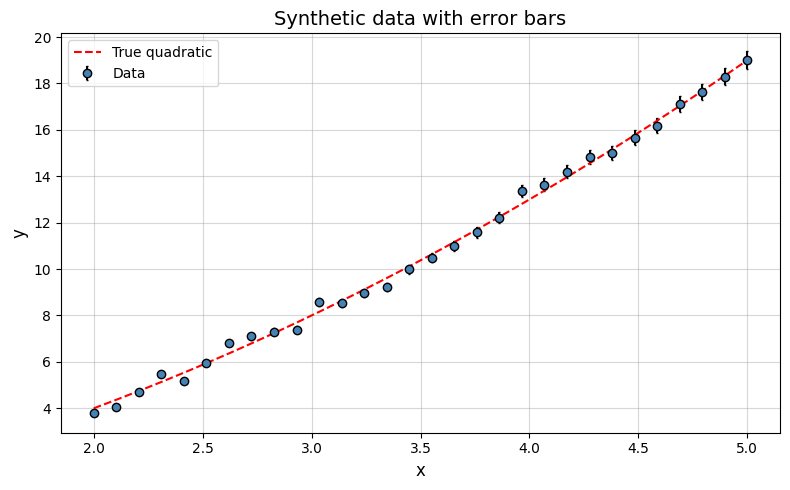

In [16]:
N = 30
x = np.linspace(2, 5, N)

c0_true = - 1.0
c1_true = 1.5
c2_true = 0.5
y_true = c0_true + c1_true * x + c2_true * x ** 2 # True quadratic model

y = y_true + np.random.normal(loc = 0, scale = 0.2, size = N) # Add Gaussian noise
errory = y / 100.0 * 2.0 # 2 % of y

# Create the plot
plt.figure(figsize = (8, 5))
plt.errorbar(x, y, yerr = errory, fmt = 'o', capsize = 1, ecolor = 'black', markeredgecolor = 'black', markerfacecolor = 'steelblue', label = 'Data')
plt.plot(x, y_true, 'r--', label = 'True quadratic', linewidth = 1.5)

plt.xlabel('x', fontsize = 12)
plt.ylabel('y', fontsize = 12)
plt.title('Synthetic data with error bars', fontsize = 14)
plt.grid(alpha = 0.5)
plt.legend()

plt.tight_layout()
plt.show()

In [17]:
def c0_formula(x, y, errory):

    w = 1.0 / errory ** 2 # Weights = 1 / Δy^2

    # Weighted sums (scalars)
    Sx   = np.sum(x * w)
    Sxx  = np.sum(x ** 2 * w)
    Sxxx = np.sum(x ** 3 * w)
    Sx4  = np.sum(x ** 4 * w)
    Sxy  = np.sum(x * y * w)
    Sxxy = np.sum(x ** 2 * y * w)
    Sy   = np.sum(y * w)
    Sw   = np.sum(w)

    # Denominator factor D (independent of the summation index)
    D = (Sxx ** 3 +
         Sxxx ** 2 * Sw +
         Sx ** 2 * Sx4 -
         Sxx * Sx4 * Sw -
         2 * Sx * Sxxx * Sxx)

    # Numerator for each data point (vectorised)
    term1 = (x ** 2 * Sxx ** 2 + Sxxx ** 2) * y
    term2 = x ** 4 * Sx * Sxy
    term3 = - x ** 3 * Sx * Sxxy
    term4 = - x ** 2 * Sxxx * Sxy
    term5 = - x ** 2 * Sx4 * Sy
    Num_i = term1 + term2 + term3 + term4 + term5

    # Sum over i of Num_i / Δy_i^2 = Num_i * w_i
    numerator_sum = np.sum(Num_i * w)

    return numerator_sum / D

def c1_formula(x, y, errory):

    w = 1.0 / errory ** 2 # Weights

    # Weighted sums (scalars)
    Sx   = np.sum(x * w)
    Sxx  = np.sum(x ** 2 * w)
    Sxxx = np.sum(x ** 3 * w)
    Sx4  = np.sum(x ** 4 * w)
    Sy   = np.sum(y * w)
    Sxy  = np.sum(x * y * w)
    Sxxy = np.sum(x ** 2 * y * w)
    Sw   = np.sum(w)

    # Denominator D (same as in the previous problem)
    D = (Sxx ** 3 +
         Sxxx ** 2 * Sw +
         Sx ** 2 * Sx4 -
         Sxx * Sx4 * Sw -
         2 * Sx * Sxxx * Sxx)

    # Sum over i of Num_i * w_i
    numerator_sum = (Sx * Sy * Sx4 -
                     Sx * Sxxy * Sxx -
                     Sxxx * Sy * Sxx +
                     Sxx ** 2 * Sxy +
                     Sxxx * Sxxy * Sw -
                     Sx4 * Sxy * Sw)

    return numerator_sum / D

def c2_formula(x, y, errory):

    w = 1.0 / errory ** 2 # Weights

    # Weighted sums (scalars)
    Sx   = np.sum(x * w)
    Sxx  = np.sum(x ** 2 * w)
    Sxxx = np.sum(x ** 3 * w)
    Sx4  = np.sum(x ** 4 * w)
    Sy   = np.sum(y * w)
    Sxy  = np.sum(x * y * w)
    Sxxy = np.sum(x ** 2 * y * w)
    Sw   = np.sum(w)

    # Denominator D
    D = (Sxx ** 3 +
         Sxxx ** 2 * Sw +
         Sx ** 2 * Sx4 -
         Sxx * Sx4 * Sw -
         2 * Sx * Sxxx * Sxx)

    # Numerator (already summed over i)
    numerator = (- Sx * Sy * Sxxx +
                 Sx ** 2 * Sxxy -
                 Sx * Sxy * Sxx +
                 Sxx ** 2 * Sy -
                 Sxx * Sxxy * Sw +
                 Sxxx * Sxy * Sw)

    return numerator / D

In [18]:
c0f = c0_formula(x, y, errory)
c0f

np.float64(-2.061420376746095)

In [19]:
c1f = c1_formula(x, y, errory)
c1f

np.float64(2.1301553595643883)

In [20]:
c2f = c2_formula(x, y, errory)
c2f

np.float64(0.41114923842393747)

In [21]:
# Fast fit using NumPy
c2n, c1n, c0n = np.polyfit(x, y,
                           w = errory,
                           deg = 2,
                           cov = False)
c0n, c1n, c2n

(np.float64(-1.5598469919434852),
 np.float64(1.8372279514499323),
 np.float64(0.45338382594594917))

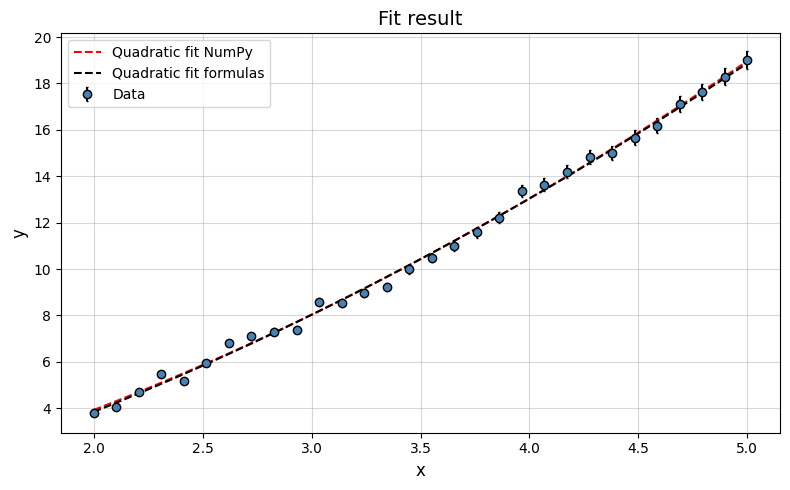

In [22]:
# Create the plot
plt.figure(figsize = (8, 5))
plt.errorbar(x, y, yerr = errory, fmt = 'o', capsize = 1, ecolor = 'black', markeredgecolor = 'black', markerfacecolor = 'steelblue', label = 'Data')
plt.plot(x, c0n + c1n * x + c2n * x ** 2, 'r--', label = 'Quadratic fit NumPy', linewidth = 1.5)
plt.plot(x, c0f + c1f * x + c2f * x ** 2, 'k--', label = 'Quadratic fit formulas', linewidth = 1.5)

plt.xlabel('x', fontsize = 12)
plt.ylabel('y', fontsize = 12)
plt.title('Fit result', fontsize = 14)
plt.grid(alpha = 0.5)
plt.legend()

plt.tight_layout()
plt.show()